模型加载完成，设备: cpu
验证集大小: (2136, 12, 1000), 标签: (2136, 10)


推理验证集: 100%|██████████| 17/17 [00:53<00:00,  3.15s/it]



===== 阈值搜索 (F1 最大化) =====
0: SR      旧阈值: 0.40 → 新阈值: 0.43  (验证F1: 0.9204)
1: NORM    旧阈值: 0.35 → 新阈值: 0.37  (验证F1: 0.8417)
2: ABQRS   旧阈值: 0.55 → 新阈值: 0.48  (验证F1: 0.4471)
3: IMI     旧阈值: 0.55 → 新阈值: 0.52  (验证F1: 0.6125)
4: ASMI    旧阈值: 0.55 → 新阈值: 0.53  (验证F1: 0.6705)
5: LVH     旧阈值: 0.55 → 新阈值: 0.57  (验证F1: 0.5060)
6: NDT     旧阈值: 0.55 → 新阈值: 0.62  (验证F1: 0.4806)
7: LAFB    旧阈值: 0.55 → 新阈值: 0.56  (验证F1: 0.7195)
8: AFIB    旧阈值: 0.50 → 新阈值: 0.49  (验证F1: 0.8133)
9: ISC_    旧阈值: 0.50 → 新阈值: 0.55  (验证F1: 0.5934)


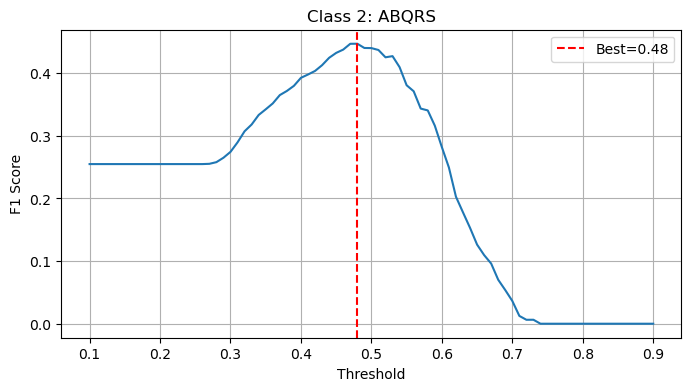

推理验证集: 100%|██████████| 17/17 [00:55<00:00,  3.25s/it]


旧阈值 (原始):
  Hamming Loss: 0.1022  Macro F1: 0.6472  Micro F1: 0.7588
  各类别 F1:
    0: SR     0.9079
    1: NORM   0.8355
    2: ABQRS  0.4211
    3: IMI    0.6033
    4: ASMI   0.6974
    5: LVH    0.4968
    6: NDT    0.4962
    7: LAFB   0.7188
    8: AFIB   0.7724
    9: ISC_   0.5227

新阈值 (优化后):
  Hamming Loss: 0.1002  Macro F1: 0.6592  Micro F1: 0.7617
  各类别 F1:
    0: SR     0.9051
    1: NORM   0.8332
    2: ABQRS  0.4770
    3: IMI    0.6349
    4: ASMI   0.7075
    5: LVH    0.5023
    6: NDT    0.4693
    7: LAFB   0.7169
    8: AFIB   0.7879
    9: ISC_   0.5578

✅ 优化后的阈值已保存至 optimized_thresholds.yaml


In [1]:
import os, sys
import numpy as np
import yaml
import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from sklearn.metrics import f1_score, precision_recall_curve
import matplotlib.pyplot as plt

# ==================== 1. 定位项目根目录 ====================
# 若之前已能运行，直接沿用 project_root 变量即可
project_root = os.path.abspath(os.path.join(os.getcwd(), "."))
# 兼容从 src/ 或项目根运行：
if not os.path.exists(os.path.join(project_root, "configs", "config.yaml")):
    project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if not os.path.exists(os.path.join(project_root, "configs", "config.yaml")):
    project_root = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), ".."))
if not os.path.exists(os.path.join(project_root, 'configs', 'config.yaml')):
    raise FileNotFoundError("请修改 project_root 为你的项目路径")
sys.path.insert(0, project_root)
os.chdir(project_root)

# ==================== 2. 加载配置与模型 ====================
with open('configs/config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = config['data']['num_classes']
class_names = config['data']['class_names']

from models.model_zoo.resnet1d import resnet34_1d, resnet18_1d
model_name = config['model']['name']
dropout = config['model'].get('dropout', 0.3)
if model_name == 'resnet34':
    model = resnet34_1d(in_channels=12, num_classes=num_classes, dropout=dropout)
else:
    model = resnet18_1d(in_channels=12, num_classes=num_classes, dropout=dropout)

best_model_path = os.path.join(config['paths']['checkpoints'], 'best_model.pth')
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()
print(f"模型加载完成，设备: {device}")

# ==================== 3. 获取验证集输出概率 ====================
data_dir = config['data']['processed_dir']
val_signals = np.load(os.path.join(data_dir, 'val', 'signals.npy')).astype(np.float32)
y_val = np.load(os.path.join(data_dir, 'labels', 'val_multilabel.npy')).astype(np.float32)  # shape (N, 10)

print(f"验证集大小: {val_signals.shape}, 标签: {y_val.shape}")

# 推理验证集
def get_probs(model, signals, batch_size=128, device='cpu'):
    dataset = TensorDataset(torch.as_tensor(signals, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_probs = []
    with torch.no_grad():
        for (batch,) in tqdm(loader, desc='推理验证集'):
            logits = model(batch.to(device))
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
    return np.concatenate(all_probs, axis=0)

val_probs = get_probs(model, val_signals, batch_size=128, device=str(device))

# ==================== 4. 逐类别搜索最优阈值（最大化 F1） ====================
# 旧阈值作为对比基线（从权威文件加载；若不存在则全 0.5）
import json as _json
def _load_old_thresholds():
    for p in ['configs/optimized_thresholds.yaml', 'configs/optimized_thresholds.yml', 'reports/optimal_thresholds.json']:
        if not os.path.exists(p):
            continue
        if p.endswith(('.yaml', '.yml')):
            with open(p, 'r', encoding='utf-8') as f:
                data = yaml.safe_load(f)
            if isinstance(data, dict):
                return np.array([float(data[str(i)]) for i in range(num_classes)])
            return np.array(list(data), dtype=float)
        elif p.endswith('.json'):
            with open(p, 'r', encoding='utf-8') as f:
                data = _json.load(f)
            if 'thresholds' in data:
                return np.array(data['thresholds'])
    return np.full(num_classes, 0.5)

old_ts = _load_old_thresholds()
print("旧阈值(基线):", old_ts)

best_thresholds = old_ts.copy()  # 初始化
search_range = np.arange(0.1, 0.91, 0.01)
print("\n===== 阈值搜索 (F1 最大化) =====")
for cls in range(num_classes):
    f1_scores = []
    for thr in search_range:
        pred = (val_probs[:, cls] >= thr).astype(int)
        f1 = f1_score(y_val[:, cls], pred, zero_division=0)
        f1_scores.append(f1)
    best_idx = np.argmax(f1_scores)
    best_thr = search_range[best_idx]
    best_f1 = f1_scores[best_idx]
    best_thresholds[cls] = best_thr
    print(f"{cls}: {class_names[cls]:6s}  旧阈值: {old_ts[cls]:.2f} → 新阈值: {best_thr:.2f}  (验证F1: {best_f1:.4f})")

# ==================== 5. 可视化（可选） ====================
# 绘制某一类的阈值-F1曲线，例如类别2 (ABQRS)
plt.figure(figsize=(8,4))
cls_plot = 2
f1_curve = [f1_score(y_val[:, cls_plot], (val_probs[:, cls_plot] >= t).astype(int), zero_division=0) for t in search_range]
plt.plot(search_range, f1_curve)
plt.axvline(best_thresholds[cls_plot], color='r', linestyle='--', label=f'Best={best_thresholds[cls_plot]:.2f}')
plt.xlabel('Threshold'); plt.ylabel('F1 Score')
plt.title(f'Class {cls_plot}: {class_names[cls_plot]}')
plt.legend(); plt.grid(True)
plt.show()

# ==================== 6. 用新阈值评估测试集 ====================
test_signals = np.load(os.path.join(data_dir, 'test', 'signals.npy')).astype(np.float32)
y_test = np.load(os.path.join(data_dir, 'labels', 'test_multilabel.npy')).astype(np.float32)
test_probs = get_probs(model, test_signals, batch_size=128, device=str(device))

# 旧阈值预测
old_preds = (test_probs >= old_ts).astype(int)
# 新阈值预测
new_preds = (test_probs >= best_thresholds).astype(int)

def print_metrics(name, y_true, y_pred):
    macro = f1_score(y_true, y_pred, average='macro')
    micro = f1_score(y_true, y_pred, average='micro')
    hamming = np.mean(y_true != y_pred)
    print(f"\n{name}:")
    print(f"  Hamming Loss: {hamming:.4f}  Macro F1: {macro:.4f}  Micro F1: {micro:.4f}")
    print("  各类别 F1:")
    for i, cls_name in enumerate(class_names):
        f1 = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
        print(f"    {i}: {cls_name:6s} {f1:.4f}")

print_metrics("旧阈值 (原始)", y_test, old_preds)
print_metrics("新阈值 (优化后)", y_test, new_preds)

# 保存新阈值配置
thresholds_dict = {i: float(best_thresholds[i]) for i in range(num_classes)}
with open('configs/optimized_thresholds.yaml', 'w', encoding='utf-8') as f:
    yaml.dump(thresholds_dict, f, allow_unicode=True)
print("\n✅ 优化后的阈值已保存至 optimized_thresholds.yaml")